In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

# Problem 2: Random Forest Ensemble (25 points)

1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the *SPAMBASE* dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [3]:
T_values = [10, 50, 100, 500]

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train.values.ravel())
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    y_train_prob = rf.predict_proba(X_train)[:,1]
    y_test_prob = rf.predict_proba(X_test)[:,1]
    
    print(f"\nRandom Forest (T={T})")
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Train F1:", f1_score(y_train, y_train_pred))
    print("Test F1:", f1_score(y_test, y_test_pred))
    print("Train AUC:", roc_auc_score(y_train, y_train_prob))
    print("Test AUC:", roc_auc_score(y_test, y_test_prob))


Random Forest (T=10)
Train Accuracy: 0.9971014492753624
Test Accuracy: 0.9417897480451781
Train F1: 0.996309963099631
Test F1: 0.9241223103057757
Train AUC: 0.9999713196716438
Test AUC: 0.9772404072835753

Random Forest (T=50)
Train Accuracy: 0.9997101449275362
Test Accuracy: 0.947002606429192
Train F1: 0.9996322177271055
Test F1: 0.9310734463276836
Train AUC: 0.9999998240470653
Test AUC: 0.9851898318153951

Random Forest (T=100)
Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9513466550825369
Train F1: 0.9996322177271055
Test F1: 0.9370786516853933
Train AUC: 0.9999998240470653
Test AUC: 0.9859419538740606

Random Forest (T=500)
Train Accuracy: 0.9997101449275362
Test Accuracy: 0.9513466550825369
Train F1: 0.9996322177271055
Test F1: 0.9367945823927766
Train AUC: 0.9999998240470652
Test AUC: 0.9863259153451861


As the number of trees increases from 10 to 100, test accuracy, F1 score, and AUC all improve, indicating that adding more trees reduces variance and improves generalization. However, beyond 100 trees, test accuracy remains the same (0.9513) and F1 changes only slightly, showing that the model’s predictions have largely stabilized and additional trees do not significantly change the majority vote. AUC continues to improve slightly, suggesting that while class predictions stay the same, the model’s predicted probabilities become more refined. Training accuracy and F1 quickly reach nearly 1.0 for all values of T, reflecting the model’s strong ability to fit the training data.

2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.

Random Forest outperforms a single unpruned decision tree on test metrics, mainly by reducing variance and improving generalization, while both models achieve near-perfect training performance. The ensemble approach provides more robust and reliable predictions, especially for AUC and F1.

3. Compute the variable importance for each feature and include a plot.

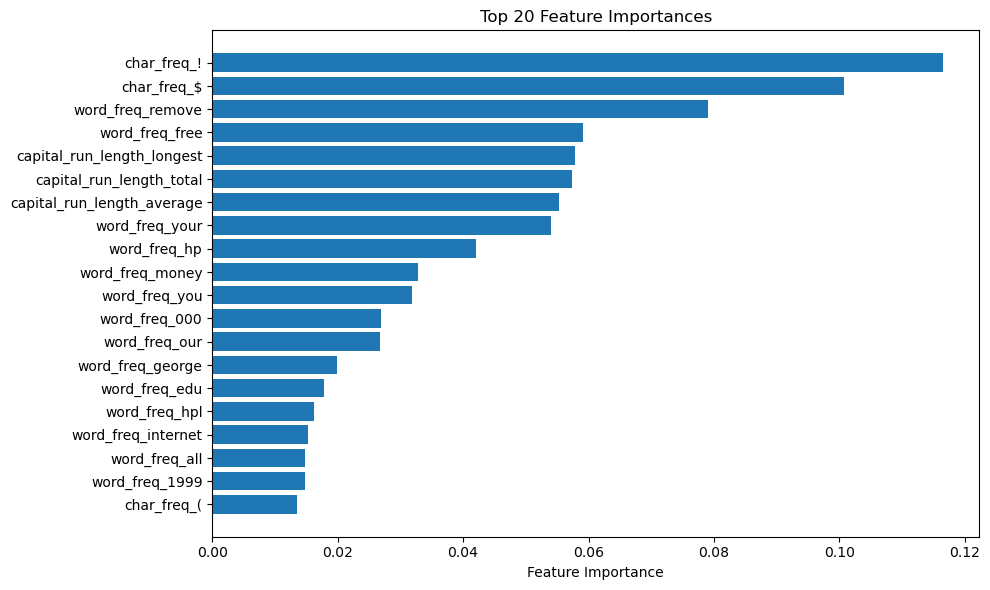

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train.values.ravel())

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(
    feature_names[indices[:20]][::-1],  # top 20, reversed for better display
    importances[indices[:20]][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()